# Chapter 42: Image Augmentation

**When does adding transformed copies of the training images raise held-out accuracy, and when does it lower it?**

A default augmentation stack can silently teach the model something false. The chapter asks for a label-preservation check per transform and for every policy to be compared with an unaugmented baseline on unchanged assessment images.

*Real small images and a linear model. Shifts hurt here, which would likely not hold for larger images or convolutional networks; the mirrored variant is constructed so that the flip is valid, and the result says nothing about natural photographs. The size of each gain and loss moves noticeably between random draws; the signs did not.*

## The experiment

scikit-learn's bundled digits dataset (1,797 real 8 x 8 grayscale scans). The control is the number of training images (100, 300 or 900); 500 other images are the test set. A multinomial logistic regression is trained on the originals alone, or on the originals plus one transformed copy of each: an unchanged duplicate (control for doubling the rows), a random shift of up to one pixel, a left-right flip, or a half-turn. This is run on the digits as scanned, and on a constructed variant in which each image, in training and test alike, is mirrored with probability one half and keeps its label. Results are means over 12 random splits.

In [1]:
import warnings

import numpy as np
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression

from kaggle_companion.activities._common import clean

warnings.filterwarnings("ignore")      # lbfgs convergence notices on tiny training sets
SEED = 42
REPLICATES = 12          # independent train/test splits per training size; results are means over them
TEST_ROWS = 500
POLICIES = ("none", "duplicate", "shift", "hflip", "rot180")


def shifted(image, rng):
    """Move the 8 x 8 image by -1, 0 or +1 pixel in each direction, padding with zeros."""
    dx, dy = rng.integers(-1, 2, 2)
    out = np.zeros_like(image)
    src = image[max(0, -dy):8 - max(0, dy), max(0, -dx):8 - max(0, dx)]
    out[max(0, dy):max(0, dy) + src.shape[0], max(0, dx):max(0, dx) + src.shape[1]] = src
    return out


TRANSFORMS = {"duplicate": lambda im, rng: im,                 # control: same rows twice, no change to the picture
              "shift": shifted,
              "hflip": lambda im, rng: im[:, ::-1],            # mirror left to right
              "rot180": lambda im, rng: im[::-1, ::-1]}        # turn upside down (a 6 becomes a 9)


def fit_predict(images, labels, test_images, policy, rng):
    """Train on the originals plus one transformed copy of each (or on the originals alone) and predict the test images."""
    if policy != "none":
        copies = np.stack([TRANSFORMS[policy](im, rng) for im in images])
        images, labels = np.concatenate([images, copies]), np.concatenate([labels, labels])
    model = LogisticRegression(max_iter=300).fit(images.reshape(len(images), -1), labels)
    return model.predict(test_images.reshape(len(test_images), -1))


def run(training_images):
    digits = load_digits()
    pictures, labels = digits.images / 16.0, digits.target     # 1,797 real 8 x 8 grayscale scans, scaled to [0, 1]
    accuracy = {v: {p: [] for p in POLICIES} for v in ("scanned", "mirrored")}
    swapped = {p: [] for p in ("none", "rot180")}              # share of true 6s and 9s predicted as the other one
    for r in range(REPLICATES):
        rng = np.random.default_rng(SEED * 100 + r)
        order = rng.permutation(len(labels))
        test, train = order[:TEST_ROWS], order[TEST_ROWS:TEST_ROWS + training_images]
        mirror = rng.random(len(labels)) < 0.5
        variants = {"scanned": pictures,                                                   # digits as scanned: orientation carries the label
                    "mirrored": np.where(mirror[:, None, None], pictures[:, :, ::-1], pictures)}   # constructed: half the images mirrored, labels unchanged
        for variant, images in variants.items():
            for policy in POLICIES:
                pred = fit_predict(images[train], labels[train], images[test], policy, np.random.default_rng(r))
                accuracy[variant][policy].append(float((pred == labels[test]).mean()))
                if variant == "scanned" and policy in swapped:
                    six_nine = np.isin(labels[test], (6, 9))
                    swapped[policy].append(float((pred[six_nine] == 15 - labels[test][six_nine]).mean()))
    mean = {v: {p: float(np.mean(a)) for p, a in d.items()} for v, d in accuracy.items()}
    return clean({"training_images": training_images, "accuracy": mean, "swapped_six_nine": {p: float(np.mean(a)) for p, a in swapped.items()},
                  "replicates": REPLICATES, "test_images": TEST_ROWS})


## Measure it across the control

The control is **training images (before augmentation)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch42 import explain

VALUES = [100, 300, 900]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                             100    300    900
No augmentation, scanned   0.882  0.933  0.960
No augmentation, mirrored  0.749  0.862  0.906
Flip, scanned              0.840  0.893  0.922
Flip, mirrored             0.840  0.893  0.922
Half-turn, scanned         0.786  0.859  0.890
6/9 swapped by half-turn     20%    11%    10%


## Look at it

The figure shows the default setting, training images (before augmentation) = 100.

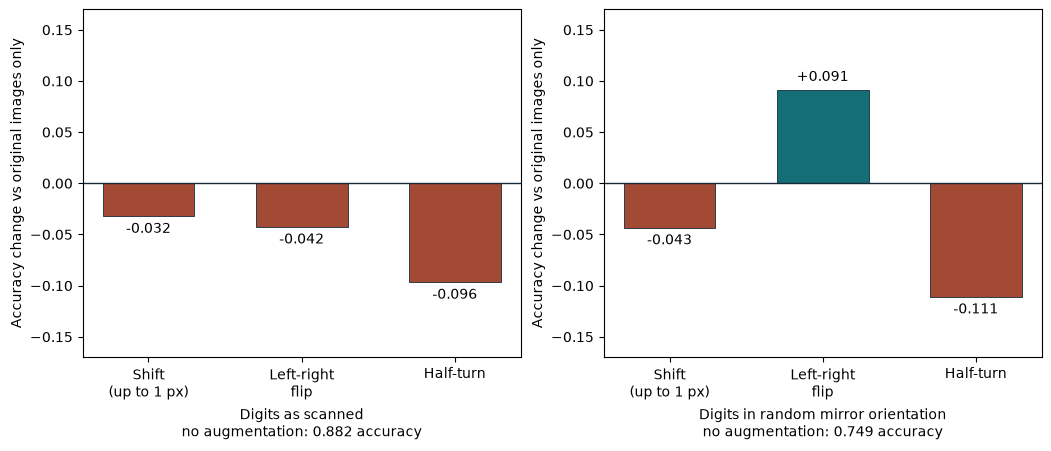

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch42 import draw, NCOLS, HEIGHT

DEFAULT = 100
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 100 training images, a left-right flip changes accuracy by 0.840 - 0.882 = -0.042 on digits as scanned and by 0.840 - 0.749 = +0.091 on digits in random mirror orientation. A one-pixel shift changes it by -0.032 and -0.043, and a half-turn by -0.096 and -0.111. The half-turn makes 20% of true 6s and 9s be predicted as the other digit, against 0% without augmentation. An unchanged duplicate of every image changes accuracy by +0.003.

- Flip on scanned digits: 0.840 - 0.882 = -0.042.
- Flip on mirrored digits: 0.840 - 0.749 = +0.091.
- Half-turn on scanned digits: 0.786 - 0.882 = -0.096.
- Unchanged duplicate on scanned digits: 0.885 - 0.882 = +0.003.

## Apply this to your competition

- Write the invariance down (class, box, mask, orientation) and check each transform on a handful of images before training.
- Compare every augmentation with an unaugmented baseline and an unchanged-duplicate control on the same untouched assessment images.
- Look at per-class errors for confusion pairs a transform could create (6 and 9, left and right, mirrored text).
- Expect valid augmentation to matter most with little data; its gain shrinks as the training set grows, while an invalid transform keeps costing accuracy.

Book location: Chapter 42, Decide Which Changes Preserve the Target.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)